In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, precision_recall_fscore_support, confusion_matrix
import json

paths = load_paths()
logger = setup_logger(level="INFO")

# Load Data and Predictions
logger.info("Loading data and predictions...")

# UPDATED: Load predictions from the Balanced Bagging output
bagging_dir = paths.artifacts_dir / "balanced_bagging"
preds_path = bagging_dir / "predictions.csv" # Changed from test_predictions.csv

if not preds_path.exists():
    raise FileNotFoundError(f"Predictions not found at {preds_path}. Run Notebook 10 first.")

df_preds = pd.read_csv(preds_path)
# Rename prob to p_calib for consistency with rest of analysis
df_preds = df_preds.rename(columns={"prob": "p_calib"})

# Load Feature Pipeline to get feature names
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline = FeaturePipeline.load(feature_art)
all_pipeline_cols = pipeline.model_feature_names()

# Filter feature columns to match what the model likely used (numeric only, no metadata)
# This replicates get_feature_cols from train_balanced_bagging_ensemble.py
exclude_cols = {"label", "capture_id", "dataset", "split", "flow_id", "timestamp", "src_ip", "dst_ip", "src_port", "dst_port", "protocol", "sample_weight"}
feature_cols = [c for c in all_pipeline_cols if c not in exclude_cols]

# Load the raw features to analyze correlations
# We need to load the features to get the feature values for the test set rows
logger.info("Loading feature data...")

def load_features_safe(dataset_name):
    p = paths.data_processed / dataset_name / "features.parquet"
    if not p.exists():
        # Try fallback
        p = paths.data_processed / dataset_name / "features_trainable.parquet"

    if p.exists():
        df = pd.read_parquet(p)
        df["dataset"] = dataset_name
        return df
    else:
        logger.warning(f"Feature file for {dataset_name} not found. Skipping feature analysis for this dataset.")
        return None

vnat_feats = load_features_safe("vnat")
iscx_feats = load_features_safe("iscx")

if vnat_feats is not None and iscx_feats is not None:
    df_features = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
    has_features = True
elif vnat_feats is not None:
    df_features = vnat_feats
    has_features = True
elif iscx_feats is not None:
    df_features = iscx_feats
    has_features = True
else:
    df_features = pd.DataFrame()
    has_features = False
    logger.warning("No feature files found. Skipping feature-level analysis.")

print(f"Predictions Shape: {df_preds.shape}")


2026-03-05 19:07:32 | INFO | ai-vpn-firewall | Loading data and predictions...
2026-03-05 19:07:32 | INFO | ai-vpn-firewall | Loading feature data...
2026-03-05 19:07:32 | WARNING | ai-vpn-firewall | Feature file for vnat not found. Skipping feature analysis for this dataset.
Predictions Shape: (19908, 5)


2026-03-05 19:07:34 | INFO | ai-vpn-firewall | Analyzing Feature Importance...
DEBUG: Mismatch detected. Model has 40, Pipeline has 39.
DEBUG: Attempting to patch with 'q_min_packets_ok'...


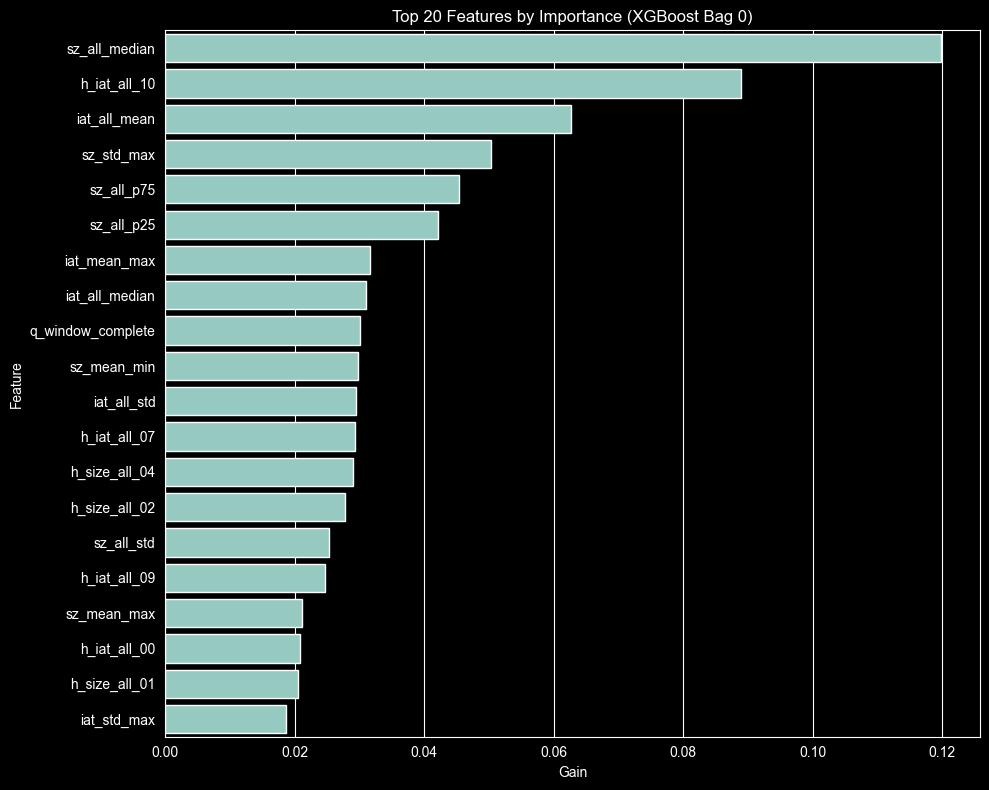

Top 5 Features:
          Feature      Gain
3   sz_all_median  0.119817
35   h_iat_all_10  0.088833
9    iat_all_mean  0.062669
7      sz_std_max  0.050354
4      sz_all_p75  0.045416

Top feature 'sz_all_median' accounts for 11.98% of total importance.


In [2]:
# 1. Feature Importance Analysis (using one of the Bagged XGBoost models)
logger.info("Analyzing Feature Importance...")
# Load the first XGBoost bag model
model_path = bagging_dir / "model_xgb_bag0.pkl"

if model_path.exists():
    model = joblib.load(model_path)

    # XGBClassifier exposes feature_importances_
    # We need to map them to feature names
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        # DEBUG: Check for mismatch
        if len(importances) != len(feature_cols):
            print(f"DEBUG: Mismatch detected. Model has {len(importances)}, Pipeline has {len(feature_cols)}.")
            # Heuristic: Check if q_min_packets_ok is missing from pipeline but likely in model
            if len(importances) == len(feature_cols) + 1:
                print("DEBUG: Attempting to patch with 'q_min_packets_ok'...")
                feature_cols.append("q_min_packets_ok")

        # Check if lengths match
        if len(importances) == len(feature_cols):
            imp_df = pd.DataFrame({
                'Feature': feature_cols,
                'Gain': importances
            }).sort_values('Gain', ascending=False)

            plt.figure(figsize=(10, 8))
            sns.barplot(x="Gain", y="Feature", data=imp_df.head(20))
            plt.title("Top 20 Features by Importance (XGBoost Bag 0)")
            plt.tight_layout()
            plt.show()

            print("Top 5 Features:")
            print(imp_df.head(5))

            # Check for "Dominator" features
            top_gain = imp_df.iloc[0]["Gain"]
            total_gain = imp_df["Gain"].sum()
            print(f"\nTop feature '{imp_df.iloc[0]['Feature']}' accounts for {top_gain/total_gain:.2%} of total importance.")
            if top_gain/total_gain > 0.5:
                print("WARNING: Single feature dominance detected! Potential leakage.")
        else:
            print(f"Feature count mismatch! Pipeline has {len(feature_cols)} features, Model has {len(importances)} features.")
            print("Cannot plot feature importance without correct mapping.")
    else:
        print("Model does not have feature_importances_ attribute.")
else:
    print(f"Model file not found: {model_path}")


In [3]:
# 2. Cross-Dataset Performance (VNAT vs ISCX)
logger.info("Analyzing Cross-Dataset Performance on TEST set...")
# Filter for TEST set
test_df = df_preds[df_preds["split"] == "test"].copy()

# Load thresholds from metrics.json
metrics_path = bagging_dir / "metrics.json"
if metrics_path.exists():
    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    # Helper to get threshold
    def get_thr(metrics_dict, fpr):
        key = f"fpr_{fpr}"
        if key in metrics_dict: return metrics_dict[key]["threshold"]
        return 0.99

    val_metrics = metrics.get("val", {})
    T_BLOCK = get_thr(val_metrics, 0.001)
    T_MONITOR = get_thr(val_metrics, 0.01)

    print(f"Global Thresholds: BLOCK={T_BLOCK:.4f}, MONITOR={T_MONITOR:.4f}")

    for ds in ["vnat", "iscx"]:
        subset = test_df[test_df["dataset"] == ds]
        if len(subset) == 0: continue

        auc_val = roc_auc_score(subset["label"], subset["p_calib"])
        print(f"\nDataset: {ds.upper()} (N={len(subset)})")
        print(f"  ROC AUC: {auc_val:.4f}")
        print(f"  Mean Prob (VPN): {subset[subset['label']==1]['p_calib'].mean():.4f}")
        print(f"  Mean Prob (Non-VPN): {subset[subset['label']==0]['p_calib'].mean():.4f}")

        for zone, t in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
            y_hat = (subset["p_calib"] >= t).astype(int)
            prec, rec, _, _ = precision_recall_fscore_support(subset["label"], y_hat, average="binary", zero_division=0)
            _, fp, _, _ = confusion_matrix(subset["label"], y_hat).ravel()
            print(f"  {zone} (p >= {t:.4f}): Recall={rec:.4f}, Precision={prec:.4f}, FP={fp}")
else:
    print("Metrics file not found. Skipping threshold analysis.")


2026-03-05 19:07:36 | INFO | ai-vpn-firewall | Analyzing Cross-Dataset Performance on TEST set...
Global Thresholds: BLOCK=0.9901, MONITOR=0.9108

Dataset: VNAT (N=801)
  ROC AUC: 0.9955
  Mean Prob (VPN): 0.9066
  Mean Prob (Non-VPN): 0.0289
  BLOCK (p >= 0.9901): Recall=0.5000, Precision=0.8571, FP=1
  MONITOR (p >= 0.9108): Recall=0.7500, Precision=0.7500, FP=3

Dataset: ISCX (N=1630)
  ROC AUC: 0.9737
  Mean Prob (VPN): 0.8263
  Mean Prob (Non-VPN): 0.0456
  BLOCK (p >= 0.9901): Recall=0.4060, Precision=1.0000, FP=0
  MONITOR (p >= 0.9108): Recall=0.5983, Precision=0.9859, FP=2


In [4]:
# 3. "Easy" vs "Hard" Traffic Analysis
logger.info("Analyzing Hard Cases...")
test_df["error"] = np.abs(test_df["label"] - test_df["p_calib"])
hard_cases = test_df[test_df["error"] > 0.5]

print(f"\nNumber of Misclassified Test Samples: {len(hard_cases)} out of {len(test_df)}")

if len(hard_cases) > 0:
    print("\nTop Misclassified Samples (by error):")
    print(hard_cases.sort_values("error", ascending=False).head(10))

    if "capture_id" in hard_cases.columns:
        print("\nMisclassifications by Capture:")
        print(hard_cases["capture_id"].value_counts().head(5))


2026-03-05 19:07:36 | INFO | ai-vpn-firewall | Analyzing Hard Cases...

Number of Misclassified Test Samples: 48 out of 2431

Top Misclassified Samples (by error):
                         capture_id dataset  label   p_calib split     error
19071     vpn_vpn_voipbuster1b.pcap    iscx      1  0.006444  test  0.993556
19105     vpn_vpn_voipbuster1b.pcap    iscx      1  0.006875  test  0.993125
19057     vpn_vpn_voipbuster1b.pcap    iscx      1  0.006900  test  0.993100
19077     vpn_vpn_voipbuster1b.pcap    iscx      1  0.006952  test  0.993048
19081     vpn_vpn_voipbuster1b.pcap    iscx      1  0.007411  test  0.992589
19062     vpn_vpn_voipbuster1b.pcap    iscx      1  0.007413  test  0.992587
19086     vpn_vpn_voipbuster1b.pcap    iscx      1  0.007433  test  0.992567
19094     vpn_vpn_voipbuster1b.pcap    iscx      1  0.007696  test  0.992304
19147  nonvpn_sftp_newcapture2.pcap    vnat      0  0.992204  test  0.992204
17678      nonvpn_ftps_down_1a.pcap    iscx      0  0.968173  test

In [5]:
# 4. Leakage Check: Correlation with Label
# We check correlations on the FULL feature set (loaded earlier)
if has_features:
    logger.info("Checking for Linear Leakage (on full dataset)...")
    corrs = []
    # We need to ensure df_features has 'label'
    if "label" in df_features.columns:
        # Sample for speed if too large
        df_sample = df_features.sample(min(10000, len(df_features)), random_state=42)

        for col in feature_cols:
            if col in df_sample.columns:
                # Ensure numeric
                if pd.api.types.is_numeric_dtype(df_sample[col]):
                    c = df_sample[col].corr(df_sample["label"])
                    corrs.append((col, c))

        corr_df = pd.DataFrame(corrs, columns=["Feature", "Correlation"]).sort_values("Correlation", key=abs, ascending=False)
        print("\nTop Correlations with Label:")
        print(corr_df.head(10))

        if not corr_df.empty and abs(corr_df.iloc[0]["Correlation"]) > 0.95:
            print(f"\nWARNING: Feature '{corr_df.iloc[0]['Feature']}' has >0.95 correlation with label. Likely leakage.")
        else:
            print("\nNo single feature has >0.95 linear correlation with label.")
    else:
        print("Label column missing in features dataframe, skipping correlation check.")
else:
    print("Skipping Leakage Check (features not loaded).")


2026-03-05 19:07:36 | INFO | ai-vpn-firewall | Checking for Linear Leakage (on full dataset)...

Top Correlations with Label:
          Feature  Correlation
26   h_iat_all_01     0.520057
18  h_size_all_00     0.413872
1      sz_all_std     0.391004
6     sz_mean_min     0.373014
33   h_iat_all_08     0.354360
20  h_size_all_02    -0.297065
2      sz_all_p25    -0.239175
25   h_iat_all_00    -0.181402
34   h_iat_all_09     0.149343
21  h_size_all_03     0.146371

No single feature has >0.95 linear correlation with label.


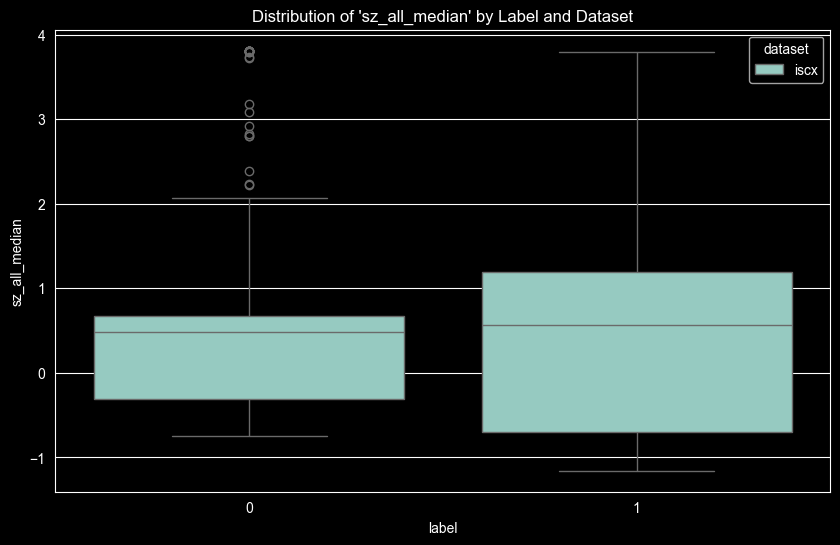

In [6]:
# 5. Distribution of Top Feature
if has_features and 'imp_df' in locals() and not imp_df.empty:
    top_feat = imp_df.iloc[0]["Feature"]
    if top_feat in df_features.columns:
        plt.figure(figsize=(10, 6))
        # Use sample for plotting
        plot_sample = df_features.sample(min(5000, len(df_features)), random_state=42)
        sns.boxplot(x="label", y=top_feat, hue="dataset", data=plot_sample)
        plt.title(f"Distribution of '{top_feat}' by Label and Dataset")
        plt.show()
else:
    print("Skipping Feature Distribution Plot (features not loaded).")
